In [1]:
import pandas as pd 
import numpy as np
import torch
from collections import OrderedDict
from typing import Dict, List, Tuple

In [2]:
# =============================================================================
# Konfigurasi path dataset
# =============================================================================
BASE_DIR = r"C:\Users\s2\Documents\Federated\dataset"

PATHS = {
    "drebin": f"{BASE_DIR}/drebin-215-dataset-5560malware-9476-benign.csv",
    "kronodroid": f"{BASE_DIR}/kronodroid.csv",
    "malgenome": f"{BASE_DIR}/malgenome.csv",
    "tuandromd": f"{BASE_DIR}/TUANDROMD 2.csv",
}


# %%
# =============================================================================
# Fungsi bantu
# =============================================================================
def load_raw(path: str) -> pd.DataFrame:
    """Baca CSV dan buang kolom index bawaan ('Unnamed: 0') kalau ada."""
    data = pd.read_csv(path)
    if "Unnamed: 0" in data.columns:
        data = data.drop(columns=["Unnamed: 0"])
    return data


def encode_label(data: pd.DataFrame, label_col: str, mapping: Dict) -> pd.DataFrame:
    """Encode kolom label sesuai mapping, mis. {'B': 0, 'S': 1}."""
    data = data.copy()
    data[label_col] = data[label_col].replace(mapping)
    return data


def to_numeric_features(data: pd.DataFrame, label_col: str) -> pd.DataFrame:
    """Paksa semua kolom selain label jadi numerik; nilai gagal -> NaN."""
    data = data.copy()
    feature_columns = [c for c in data.columns if c != label_col]
    data[feature_columns] = data[feature_columns].apply(pd.to_numeric, errors="coerce")
    return data


def report(name: str, X: np.ndarray, y: np.ndarray) -> None:
    print(f"[{name}]")
    print("  Ukuran X       :", X.shape)
    print("  Ukuran y       :", y.shape)
    print("  Distribusi kelas:", np.bincount(y))
    print()


def split_features_labels(
    data: pd.DataFrame, label_col: str
) -> Tuple[np.ndarray, np.ndarray]:
    X = data.drop(columns=[label_col]).values.astype(np.float32)
    y = data[label_col].astype(int).values
    return X, y


In [3]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

from dataset import split_and_prepare_data
# =============================================================================
# 1. Dataset Drebin
# =============================================================================
LABEL_COLUMN = "class"  # sesuaikan dengan nama kolom label sebenarnya di file Drebin
SPECIAL_COLUMN = "TelephonyManager.getSimCountryIso"
 
data = load_raw(PATHS["drebin"])
 
if SPECIAL_COLUMN in data.columns:
    data[SPECIAL_COLUMN] = data[SPECIAL_COLUMN].replace("?", np.nan)
    data[SPECIAL_COLUMN] = pd.to_numeric(data[SPECIAL_COLUMN], errors="coerce")
 
if LABEL_COLUMN not in data.columns:
    raise KeyError(f"Kolom '{LABEL_COLUMN}' tidak ditemukan. Kolom tersedia: {list(data.columns)}")
 
data = encode_label(data, LABEL_COLUMN, {"B": 0, "S": 1})
data = to_numeric_features(data, LABEL_COLUMN)
data = data.dropna().reset_index(drop=True)
 
X_drebin, y_drebin = split_features_labels(data, LABEL_COLUMN)
N_CLASSES = len(np.unique(y_drebin))
N_FEATURES = X_drebin.shape[1]
 
report("Drebin", X_drebin, y_drebin)
print("Jumlah kelas:", N_CLASSES)
 
drebin_split = split_and_prepare_data(X_drebin, y_drebin)
 
 
# %%
# =============================================================================
# 2. Dataset KronoDroid
# =============================================================================
LABEL_COL_KRONO = "Malware"
 
data = load_raw(PATHS["kronodroid"])
print("Ukuran data awal:", data.shape)
print("\nMissing value sebelum drop:", data.isna().sum().sum())
 
data = data.dropna().reset_index(drop=True)
print("Missing value setelah drop:", data.isna().sum().sum())
 
print("\nNilai unik Malware:", data[LABEL_COL_KRONO].unique())
print("Distribusi kelas Malware:\n", data[LABEL_COL_KRONO].value_counts())
 
data = to_numeric_features(data, LABEL_COL_KRONO)
data = data.dropna().reset_index(drop=True)
 
X_krono, y_krono = split_features_labels(data, LABEL_COL_KRONO)
target_names_krono = ["goodware", "malware"]
 
report("KronoDroid", X_krono, y_krono)
print("Jumlah fitur:", X_krono.shape[1])
 
krono_split = split_and_prepare_data(X_krono, y_krono)
 
 
# %%
# =============================================================================
# 3. Dataset MalGenome
# =============================================================================
LABEL_COL_MALGENOME = "class"
 
data = load_raw(PATHS["malgenome"])
print("Missing value per kolom:\n", data.isna().sum())
 
data = encode_label(data, LABEL_COL_MALGENOME, {"B": 0, "S": 1})
data = to_numeric_features(data, LABEL_COL_MALGENOME)
data = data.dropna().reset_index(drop=True)
 
X_malgenome, y_malgenome = split_features_labels(data, LABEL_COL_MALGENOME)
target_names_malgenome = ["benign", "malware"]
 
report("MalGenome", X_malgenome, y_malgenome)
 
malgenome_split = split_and_prepare_data(X_malgenome, y_malgenome)

# =============================================================================
# 4. Dataset TUANDROMD
# =============================================================================
LABEL_COL_TUANDROMD = "Label"
 
data = load_raw(PATHS["tuandromd"])
print("Missing value sebelum drop:", data.isna().sum().sum())
 
data = data.dropna().reset_index(drop=True)
print("Missing value setelah drop:", data.isna().sum().sum())
 
print("Nilai unik Label:", data[LABEL_COL_TUANDROMD].unique())
 
data = encode_label(data, LABEL_COL_TUANDROMD, {"goodware": 0, "malware": 1})
data = to_numeric_features(data, LABEL_COL_TUANDROMD)
data = data.dropna().reset_index(drop=True)
 
X_tuandromd, y_tuandromd = split_features_labels(data, LABEL_COL_TUANDROMD)
target_names_tuandromd = ["goodware", "malware"]
 
report("TUANDROMD", X_tuandromd, y_tuandromd)
 
tuandromd_split = split_and_prepare_data(X_tuandromd, y_tuandromd)

C:\Users\s2\AppData\Local\Temp\ipykernel_36112\1764348774.py:20: DtypeWarning: Columns (92: TelephonyManager.getSimCountryIso) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(path)


[Drebin]
  Ukuran X       : (15031, 215)
  Ukuran y       : (15031,)
  Distribusi kelas: [9476 5555]

Jumlah kelas: 2
Train: torch.Size([10521, 215]) | Val: torch.Size([2255, 215]) | Test: torch.Size([2255, 215])
Ukuran data awal: (78137, 463)

Missing value sebelum drop: 0
Missing value setelah drop: 0

Nilai unik Malware: [1 0]
Distribusi kelas Malware:
 Malware
1    41382
0    36755
Name: count, dtype: int64
[KronoDroid]
  Ukuran X       : (78137, 462)
  Ukuran y       : (78137,)
  Distribusi kelas: [36755 41382]

Jumlah fitur: 462
Train: torch.Size([54695, 462]) | Val: torch.Size([11721, 462]) | Test: torch.Size([11721, 462])
Missing value per kolom:
 transact                                 0
bindService                              0
onServiceConnected                       0
ServiceConnection                        0
android.os.Binder                        0
                                        ..
GLOBAL_SEARCH                            0
GET_PACKAGE_SIZE                   

In [4]:
# Ringkasan semua split
# =============================================================================
all_splits = {
    "drebin": drebin_split,
    "kronodroid": krono_split,
    "malgenome": malgenome_split,
    "tuandromd": tuandromd_split,
}
 
for name, split in all_splits.items():
    print(f"\n[{name}]")
    print("  X_train:", split["X_train_t"].shape)
    print("  X_val  :", split["X_val_t"].shape)
    print("  X_test :", split["X_test_t"].shape)


[drebin]
  X_train: torch.Size([10521, 215])
  X_val  : torch.Size([2255, 215])
  X_test : torch.Size([2255, 215])

[kronodroid]
  X_train: torch.Size([54695, 462])
  X_val  : torch.Size([11721, 462])
  X_test : torch.Size([11721, 462])

[malgenome]
  X_train: torch.Size([2659, 215])
  X_val  : torch.Size([570, 215])
  X_test : torch.Size([570, 215])

[tuandromd]
  X_train: torch.Size([3124, 241])
  X_val  : torch.Size([670, 241])
  X_test : torch.Size([670, 241])


In [5]:
from fl_running6 import run_federated, export_history_csv, export_per_client_csv
import pandas as pd
import matplotlib.pyplot as plt

# Dataset = client. Ambil n_features dari tiap dataset yang sudah dihitung sebelumnya.
n_features_map = {
    "drebin":     X_drebin.shape[1],
    "kronodroid": X_krono.shape[1],
    "malgenome":  X_malgenome.shape[1],
    "tuandromd":  X_tuandromd.shape[1],
}

fed_data = {}
for name, split in all_splits.items():
    fed_data[name] = {
        "X_train": split["X_train_t"], "y_train": split["y_train_t"],
        "X_val":   split["X_val_t"],   "y_val":   split["y_val_t"],
        "X_test":  split["X_test_t"],  "y_test":  split["y_test_t"],
        "n_features": n_features_map[name],
    }

for name, c in fed_data.items():
    print(name, "n_features =", c["n_features"],
          "train", tuple(c["X_train"].shape))

# %%
COMMON = dict(
    common_dim=128,      # dimensi bersama untuk theta; boleh dicoba 64/128/256
    n_classes=2,
    num_rounds=20,
    local_epochs=2,
)

h_fedper = run_federated(fed_data, name="FedPer", **COMMON)

2026-10-01 17:38:38,373	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


drebin n_features = 215 train (10521, 215)
kronodroid n_features = 462 train (54695, 462)
malgenome n_features = 215 train (2659, 215)
tuandromd n_features = 241 train (3124, 241)


INFO :      Starting Flower ServerApp, config: num_rounds=20, no round_timeout
INFO :      
INFO :      [INIT]
INFO :      Using initial global parameters provided by strategy
INFO :      Evaluating initial global parameters
INFO :      
INFO :      [ROUND 1]
INFO :      configure_fit: strategy sampled 4 clients (out of 4)
INFO :      aggregate_fit: received 4 results and 0 failures
INFO :      fit progress: (1, 0.15393717773258686, {'accuracy': 0.943080503232659, 'precision': 0.9449726637966808, 'recall': 0.9391949356307923, 'f1': 0.9387496099445768}, 11.834556500078179)
INFO :      configure_evaluate: no clients selected, skipping evaluation
INFO :      
INFO :      [ROUND 2]
INFO :      configure_fit: strategy sampled 4 clients (out of 4)


[FedPer] round 01 | loss=0.1539 acc=0.9431 f1=0.9387 | comm=0.315MB (cum 0.315MB)


INFO :      aggregate_fit: received 4 results and 0 failures
INFO :      fit progress: (2, 0.10068292822688818, {'accuracy': 0.9670094873916986, 'precision': 0.9738923810558753, 'recall': 0.9574120441859084, 'f1': 0.9642695324725141}, 15.878486600006)
INFO :      configure_evaluate: no clients selected, skipping evaluation
INFO :      
INFO :      [ROUND 3]
INFO :      configure_fit: strategy sampled 4 clients (out of 4)


...

[FedPer] round 18 | loss=0.2055 acc=0.9765 f1=0.9725 | comm=0.315MB (cum 5.678MB)


INFO :      aggregate_fit: received 4 results and 0 failures
INFO :      fit progress: (19, 0.17034742003306746, {'accuracy': 0.9784758892909239, 'precision': 0.9696212701730967, 'recall': 0.9813462681673282, 'f1': 0.9750372124019422}, 93.64698770001996)
INFO :      configure_evaluate: no clients selected, skipping evaluation
INFO :      
INFO :      [ROUND 20]
INFO :      configure_fit: strategy sampled 4 clients (out of 4)


[FedPer] round 19 | loss=0.1703 acc=0.9785 f1=0.9750 | comm=0.315MB (cum 5.993MB)


INFO :      aggregate_fit: received 4 results and 0 failures
INFO :      fit progress: (20, 0.17817912716418505, {'accuracy': 0.97908664402197, 'precision': 0.9678554561126036, 'recall': 0.9839421832854295, 'f1': 0.9754843586816855}, 98.70224780007266)
INFO :      configure_evaluate: no clients selected, skipping evaluation
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 20 round(s) in 98.70s
INFO :      	History (loss, centralized):
INFO :      		round 1: 0.15393717773258686
INFO :      		round 2: 0.10068292822688818
INFO :      		round 3: 0.10390417231246829
INFO :      		round 4: 0.10089013865217566
INFO :      		round 5: 0.10132001619786024
INFO :      		round 6: 0.10665350826457143
INFO :      		round 7: 0.1097860112786293
INFO :      		round 8: 0.11635020561516285
INFO :      		round 9: 0.15550448186695576
INFO :      		round 10: 0.14602439478039742
INFO :      		round 11: 0.15893498435616493
INFO :      		round 12: 0.16990178800188005
INFO :      		round 13: 0.187675

[FedPer] round 20 | loss=0.1782 acc=0.9791 f1=0.9755 | comm=0.315MB (cum 6.309MB)
[FedPer] BANDWIDTH | theta=0.039MB up=3.15MB down=3.15MB total=6.31MB (~0.32MB/ronde)


Metrics per-round CSV : None
Per-client val CSV    : None
[export] metrik per-ronde tersimpan di: FedPer_metrics_per_round.csv
[export] metrik per-client tersimpan di: FedPer_val_per_client.csv
    round      loss  accuracy  precision    recall        f1  bytes_up_MB  \
0       1  0.153937  0.943081   0.944973  0.939195  0.938750     0.157715   
1       2  0.100683  0.967009   0.973892  0.957412  0.964270     0.157715   
2       3  0.103904  0.971844   0.969765  0.969297  0.968768     0.157715   
3       4  0.100890  0.973440   0.971590  0.969934  0.970076     0.157715   
4       5  0.101320  0.972921   0.965729  0.974474  0.969241     0.157715   
5       6  0.106654  0.975668   0.976197  0.970270  0.972605     0.157715   
6       7  0.109786  0.977411   0.977333  0.973041  0.974764     0.157715   
7       8  0.116350  0.978589   0.972844  0.978205  0.975162     0.157715   
8       9  0.155504  0.977168   0.970717  0.977560  0.973602     0.157715   
9      10  0.146024  0.979222   0.97

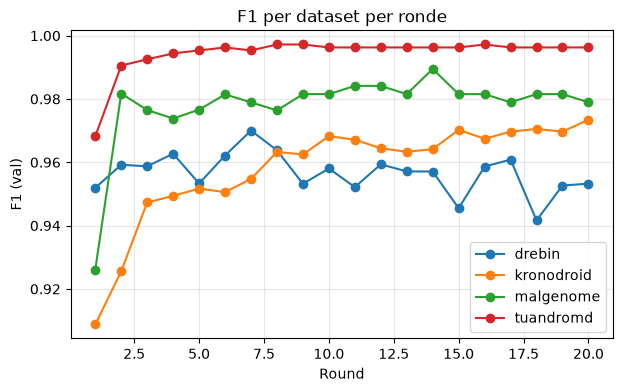

In [6]:
# =============================================================================
# Ekspor CSV: metrik per-ronde (accuracy, precision, recall, f1) + bandwidth
# =============================================================================
# run_federated() sudah otomatis mengekspor ke:
#   FedPer_metrics_per_round.csv   -> loss/accuracy/precision/recall/f1 + bandwidth per ronde
#   FedPer_val_per_client.csv      -> metrik val per client per ronde
# Path-nya juga tersimpan di dalam history:
print("Metrics per-round CSV :", h_fedper.get("metrics_csv_path"))
print("Per-client val CSV    :", h_fedper.get("per_client_csv_path"))

# Kalau mau simpan ke lokasi/nama lain secara eksplisit:
export_history_csv(h_fedper, "FedPer_metrics_per_round.csv")
export_per_client_csv(h_fedper, "FedPer_val_per_client.csv", split="val_per_client")

df_metrics = pd.read_csv("FedPer_metrics_per_round.csv")
print(df_metrics)

# %%
# =============================================================================
# Plot: F1 per dataset per ronde (dari val_per_client)
# =============================================================================
rows = []
for r, vc in zip(h_fedper["round"], h_fedper["val_per_client"]):
    for cname, m in vc.items():
        rows.append({"round": r, "dataset": cname, **m})
df_val = pd.DataFrame(rows)
df_val.to_csv("FedPer_val_per_client_long.csv", index=False)  # versi long-format, opsional

fig, ax = plt.subplots(figsize=(7, 4))
for cname, g in df_val.groupby("dataset"):
    ax.plot(g["round"], g["f1"], marker="o", label=cname)
ax.set_xlabel("Round"); ax.set_ylabel("F1 (val)")
ax.set_title("F1 per dataset per ronde"); ax.legend(); ax.grid(alpha=0.3)
plt.savefig("FedPer_f1_per_round.png", dpi=150, bbox_inches="tight")
plt.show()

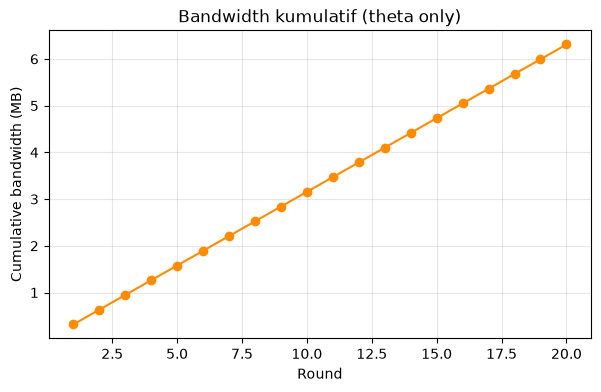

            accuracy  precision  recall      f1
dataset                                        
drebin        0.9650     0.9189  0.9928  0.9544
kronodroid    0.9709     0.9877  0.9570  0.9721
malgenome     0.9789     0.9683  0.9683  0.9683
tuandromd     0.9985     0.9981  1.0000  0.9991

CSV berhasil disimpan sebagai: test_per_client_fedper.csv

Semua file CSV yang dihasilkan:
 - FedPer_metrics_per_round.csv   (metrik + bandwidth per ronde)
 - FedPer_val_per_client.csv      (metrik val per client per ronde)
 - FedPer_val_per_client_long.csv (versi long-format untuk plotting)
 - test_per_client_fedper.csv     (metrik test akhir per client)


In [7]:
# =============================================================================
# Plot: Bandwidth kumulatif per ronde
# =============================================================================
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(df_metrics["round"], df_metrics["cum_MB"], marker="o", color="darkorange")
ax.set_xlabel("Round"); ax.set_ylabel("Cumulative bandwidth (MB)")
ax.set_title("Bandwidth kumulatif (theta only)"); ax.grid(alpha=0.3)
plt.savefig("FedPer_bandwidth_cumulative.png", dpi=150, bbox_inches="tight")
plt.show()

# %%
# =============================================================================
# Ringkasan akhir: metrik test per client
# =============================================================================
df_test = pd.DataFrame(h_fedper["test_per_client"]).T
df_test.index.name = "dataset"
df_test = df_test[["accuracy", "precision", "recall", "f1"]].round(4)
print(df_test)

df_test.to_csv("test_per_client_fedper.csv", index=True)
print("\nCSV berhasil disimpan sebagai: test_per_client_fedper.csv")

print("\nSemua file CSV yang dihasilkan:")
print(" - FedPer_metrics_per_round.csv   (metrik + bandwidth per ronde)")
print(" - FedPer_val_per_client.csv      (metrik val per client per ronde)")
print(" - FedPer_val_per_client_long.csv (versi long-format untuk plotting)")
print(" - test_per_client_fedper.csv     (metrik test akhir per client)")